In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [7]:
base_dir = '../data/s1/original/'

dfs = []
files = next(os.walk(base_dir))[2]

for file in files:
    dfs.append(pd.read_csv(os.path.join(base_dir, file), encoding='utf-8'))

In [10]:
original_df = pd.concat(dfs, ignore_index=True, sort=True)

                 x            y      cluster          _id
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.673449     0.613188    14.050000  4499.500000
std       0.200158     0.210328     0.805076   288.819436
min       0.272747     0.290600    13.000000  4000.000000
25%       0.423590     0.411789    13.000000  4249.750000
50%       0.695405     0.540911    14.000000  4499.500000
75%       0.877048     0.869367    15.000000  4749.250000
max       1.000000     1.000000    15.000000  4999.000000
cluster
14    350
15    350
13    300
Name: count, dtype: int64
                 x            y      cluster          _id
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.641877     0.565991     2.154000   499.500000
std       0.174903     0.209603     0.933357   288.819436
min       0.328162     0.167528     1.000000     0.000000
25%       0.445686     0.307997     1.000000   249.750000
50%       0.624741     0.570947     2.000000   499.500000
75%     

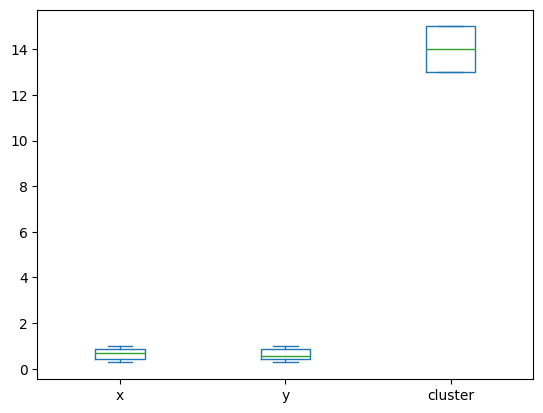

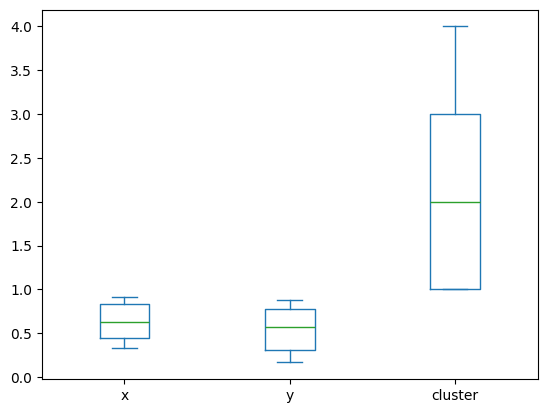

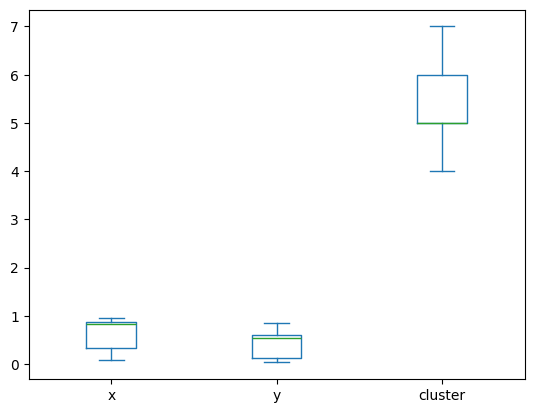

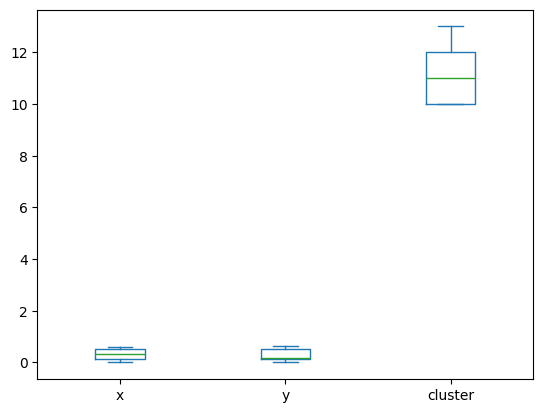

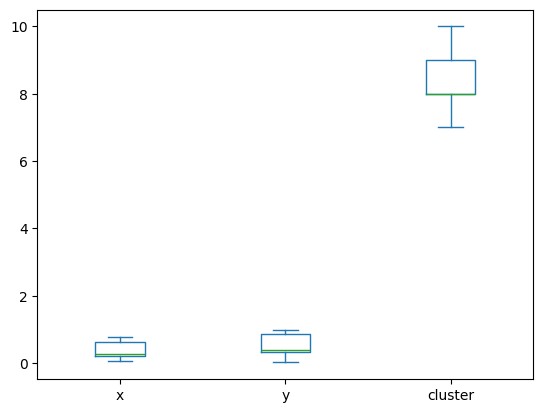

In [12]:
for df in dfs:
    print(df.describe())
    df[df.columns[0:-1]].plot.box()
    print(df['cluster'].value_counts())

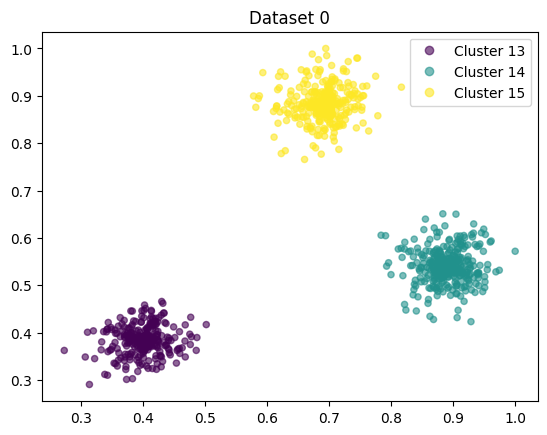

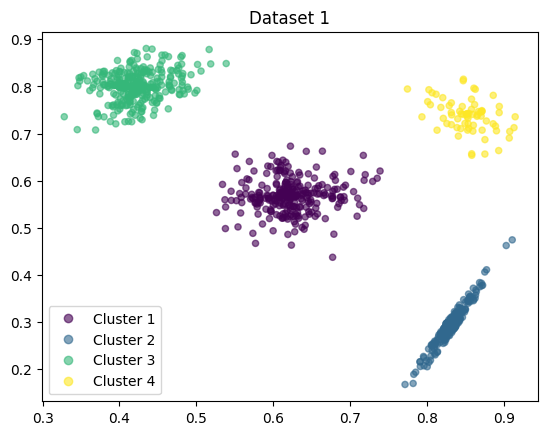

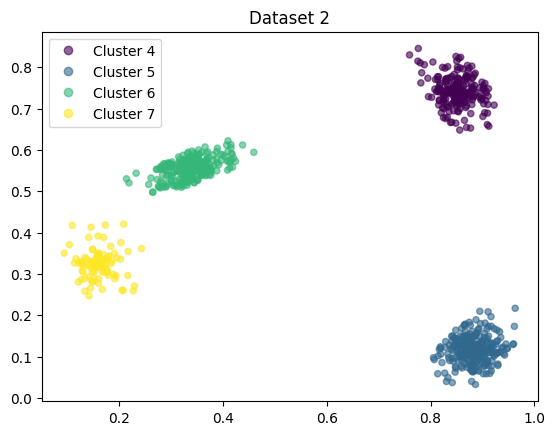

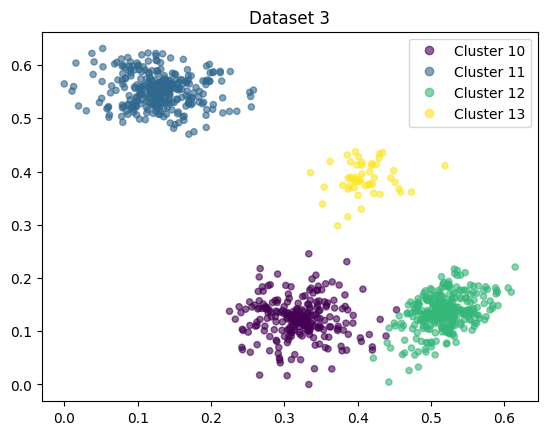

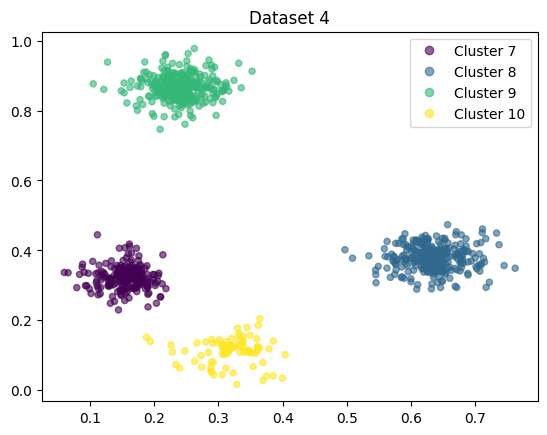

In [10]:
for index, df in enumerate(dfs):
    fig, ax = plt.subplots()
    scatter = plt.scatter(df["x"], df["y"], c=df['cluster'], alpha = 0.6, s=20)
    ax.legend(handles=scatter.legend_elements()[0], labels=map(lambda x: 'Cluster ' + str(x), df['cluster'].unique()))
    ax.set_title(f"Dataset {index}")

In [15]:
base_dir = 'data/'

dfs = []
files = next(os.walk(base_dir))[2]

for file in files:
    dfs.append(pd.read_csv(os.path.join(base_dir, file), encoding='utf-8'))


In [16]:
df = pd.concat(dfs, ignore_index=True, sort=False)
df.head()

,Unnamed: 0,x,y,cluster,_id,actual_cluster,cluster_ids
0,0,0.683912,0.543504,145,0,1,0
1,1,0.685701,0.551136,145,1,1,0
2,2,0.612810,0.570245,145,2,1,0
3,3,0.635553,0.544047,145,3,1,0
4,4,0.653693,0.605594,145,4,1,0


In [13]:
original_df = original_df.sort_values(by='_id')
original_df.head()

,_id,cluster,x,y
1000,0,1,0.683912,0.543504
1001,1,1,0.685701,0.551136
1002,2,1,0.612810,0.570245
1003,3,1,0.635553,0.544047
1004,4,1,0.653693,0.605594


In [18]:
true = original_df['cluster']
pred = df['cluster']

(len(pred & true)) / (len(true) + len(pred) - len(true & pred))

/var/folders/m0/vdxkcl8x2f3g24hptwxr98400000gn/T/ipykernel_13745/2822520538.py:4: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  (len(pred & true)) / (len(true) + len(pred) - len(true & pred))
/var/folders/m0/vdxkcl8x2f3g24hptwxr98400000gn/T/ipykernel_13745/2822520538.py:4: FutureWarning: Operation between non boolean Series with different indexes will no longer return a boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  (len(pred & true)) / (len(true) + len(pred) - len(true & pred))


1.0

In [ ]:

def jaccard_measure(pred, true):
	value = (len(pred & true)) / (len(true) + len(pred) - len(true & pred))
	return value